In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
# Load the dataset from the CSV file
# sep=';' -> The UCI dataset uses semicolons instead of commas as delimiters
# decimal=',' -> European formatting uses commas for decimals (e.g., 2,5 instead of 2.5)
# header=0 -> Sets the first row as the column names
df = pd.read_csv(
    "AirQualityUCI.csv",
    sep=';',
    decimal=',',
    header=0
)

# Remove last two empty columns
# The UCI CSV file contains two trailing empty columns due to extra semicolons
df = df.iloc[:, :-2]

# Clean the column headers by removing any leading or trailing whitespace
# This prevents errors when trying to access columns like df['CO(GT)']
df.columns = df.columns.str.strip()

print(df.columns)



Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')


In [3]:
# Standardise the Time format by replacing dots with colons (e.g., 18.00.00 -> 18:00:00)
# This ensures the string is in a standard format that pandas can recognize as time
df["Time"] = df["Time"].str.replace(".", ":", regex=False)
# Create a single 'Datetime' column by merging 'Date' and 'Time' strings
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)
print(df["Datetime"].head())


0   2004-03-10 18:00:00
1   2004-03-10 19:00:00
2   2004-03-10 20:00:00
3   2004-03-10 21:00:00
4   2004-03-10 22:00:00
Name: Datetime, dtype: datetime64[ns]


In [4]:
#removing data and time column 
df.drop(columns=["Date", "Time"], inplace=True)
print(df.columns)

Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH', 'Datetime'],
      dtype='object')


In [5]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,2004-09-21 16:00:00
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,2004-03-10 18:00:00
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,2004-06-16 05:00:00
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,2004-09-21 16:00:00
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN


In [6]:
# Replace placeholder value -200 with NaN (Not a Number) to represent missing data
df.replace(-200, np.nan, inplace=True)
for col in df.columns:
    # Skip the Datetime column
    if col != "Datetime":
         dfcol= df[col].astype(float)
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,2004-09-21 16:00:00
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,2004-06-16 05:00:00
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,2004-09-21 16:00:00
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,NaN


In [7]:
# Define a function to calculate and display a summary of missing data
def missing_values_table(data):
    # Calculate the total count of null values per column
    mis_val=data.isnull().sum()
    # Calculate the percentage of missing values relative to the total rows
    mis_val_percent=100*data.isnull().sum()/len(data)
    # Concatenate the count and percentage into a single DataFrame for comparison
    mis_val_table=pd.concat([mis_val,mis_val_percent],axis=1)
    mis_val_table_ren_columns=mis_val_table.rename(columns={0:'Missing Values',1:'% of Total Values'})
    # Filter the table to only show columns with at least one missing value
    mis_val_table_ren_columns=mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,1]!=0].sort_values('% of Total Values', ascending=False).round(1)
    print("Your selected dataframe has" + str(df.shape[1])+"columns.\n""These are" + str(mis_val_table_ren_columns.shape[0])+"columns that have missing values.")
    return mis_val_table_ren_columns
missing_values_table(df)

Your selected dataframe has14columns.
These are14columns that have missing values.


,Missing Values,% of Total Values
NMHC(GT),8557,90.3
CO(GT),1797,19.0
NO2(GT),1756,18.5
NOx(GT),1753,18.5
PT08.S1(CO),480,5.1
C6H6(GT),480,5.1
PT08.S2(NMHC),480,5.1
PT08.S3(NOx),480,5.1
PT08.S4(NO2),480,5.1
PT08.S5(O3),480,5.1


In [8]:
#Identify columns with more than 50% missing data based on the summary table
missing_df=missing_values_table(df);
missing_columns=list(missing_df[missing_df['% of Total Values']>50].index)
# Print the count of highly incomplete columns identified for removal
print('We will remove %d columns.'%len(missing_columns))
# Drop these redundant columns from the main dataframe to reduce data noise
df=df.drop(columns=list(missing_columns))


Your selected dataframe has14columns.
These are14columns that have missing values.
We will remove 1 columns.


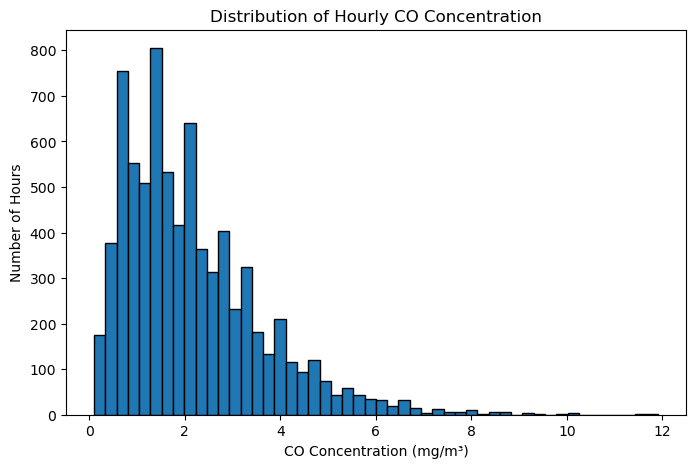

In [9]:
df = df.rename(columns={'CO(GT)': 'CO'})
# Histogram of hourly CO concentration
plt.figure(figsize=(8,5))
plt.hist(df['CO'].dropna(), bins=50, edgecolor='k')
plt.xlabel('CO Concentration (mg/m³)')
plt.ylabel('Number of Hours')
plt.title('Distribution of Hourly CO Concentration')
plt.show()

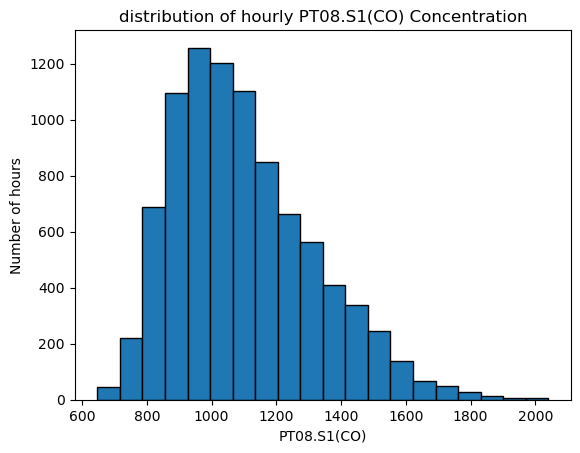

In [10]:
#histogram of hourly PT08.S1(CO) concentration
plt.hist(df['PT08.S1(CO)'].dropna(), bins = 20, edgecolor = 'black');
plt.xlabel('PT08.S1(CO)');
plt.ylabel('Number of hours'); 
plt.title('distribution of hourly PT08.S1(CO) Concentration');
plt.show()


In [11]:
# START CLEAN
df = df.copy()

# Make sure Datetime is datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Extract hour and month
df['hour'] = df['Datetime'].dt.hour
df['month'] = df['Datetime'].dt.month
# Identify numeric sensor data, excluding the extracted time features for separate processing
numeric_subset = df.select_dtypes(include=['number']).drop(columns=['hour', 'month'])
# Feature engineering
for col in numeric_subset.columns:
    if col == 'CO':
        continue
    numeric_subset['sqrt_' + col] = np.sqrt(numeric_subset[col].where(numeric_subset[col] >= 0))
    numeric_subset['log_' + col] = np.log(numeric_subset[col].where(numeric_subset[col] > 0))
categorical_subset = pd.get_dummies(df[['hour', 'month']], drop_first=True)

features = pd.concat([numeric_subset, categorical_subset], axis=1)

# Add Datetime separately (not used in model, but kept for time split)
features['Datetime'] = df['Datetime']

print(features.columns)

Index(['CO', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
       'AH', 'sqrt_PT08.S1(CO)', 'log_PT08.S1(CO)', 'sqrt_C6H6(GT)',
       'log_C6H6(GT)', 'sqrt_PT08.S2(NMHC)', 'log_PT08.S2(NMHC)',
       'sqrt_NOx(GT)', 'log_NOx(GT)', 'sqrt_PT08.S3(NOx)', 'log_PT08.S3(NOx)',
       'sqrt_NO2(GT)', 'log_NO2(GT)', 'sqrt_PT08.S4(NO2)', 'log_PT08.S4(NO2)',
       'sqrt_PT08.S5(O3)', 'log_PT08.S5(O3)', 'sqrt_T', 'log_T', 'sqrt_RH',
       'log_RH', 'sqrt_AH', 'log_AH', 'hour', 'month', 'Datetime'],
      dtype='object')


In [12]:
# Find correlations with the score
correlations = features.corr()['CO'].dropna().sort_values()
# Display most negative correlations
correlations.head(15)

log_PT08.S3(NOx)    -0.780496
sqrt_PT08.S3(NOx)   -0.746716
PT08.S3(NOx)        -0.703446
T                    0.022109
sqrt_T               0.039323
Datetime             0.045123
log_RH               0.046581
sqrt_RH              0.047936
AH                   0.048556
RH                   0.048890
sqrt_AH              0.061389
log_T                0.063141
log_AH               0.073648
month                0.111211
hour                 0.358159
Name: CO, dtype: float64

In [13]:
# Display most positive correlations
correlations.tail(15)

sqrt_NOx(GT)          0.794502
NOx(GT)               0.795028
log_PT08.S5(O3)       0.795480
log_C6H6(GT)          0.828954
sqrt_PT08.S5(O3)      0.831875
PT08.S5(O3)           0.854182
log_PT08.S1(CO)       0.859293
sqrt_PT08.S1(CO)      0.870767
log_PT08.S2(NMHC)     0.872642
PT08.S1(CO)           0.879288
sqrt_PT08.S2(NMHC)    0.897366
sqrt_C6H6(GT)         0.909028
PT08.S2(NMHC)         0.915514
C6H6(GT)              0.931078
CO                    1.000000
Name: CO, dtype: float64

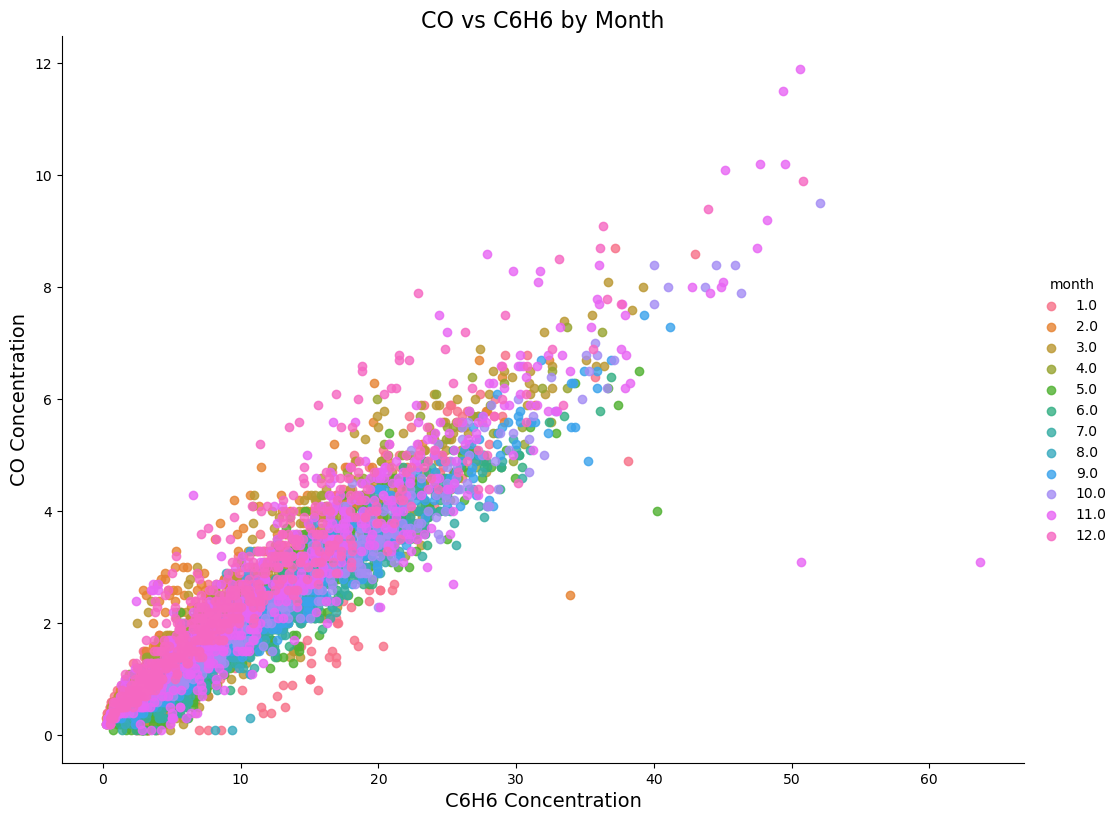

In [14]:
# Make sure month column exists
df['month'] = df['Datetime'].dt.month

# Scatter plot with month as third variable
sns.lmplot(
    x='C6H6(GT)',
    y='CO',
    hue='month',
    data=df,
    fit_reg=False,
    height=8,
    aspect=1.3
)

plt.xlabel("C6H6 Concentration", size=14)
plt.ylabel("CO Concentration", size=14)
plt.title("CO vs C6H6 by Month", size=16)
plt.show()

Text(0.5, 1.02, 'Pairs Plot of Energy Data')

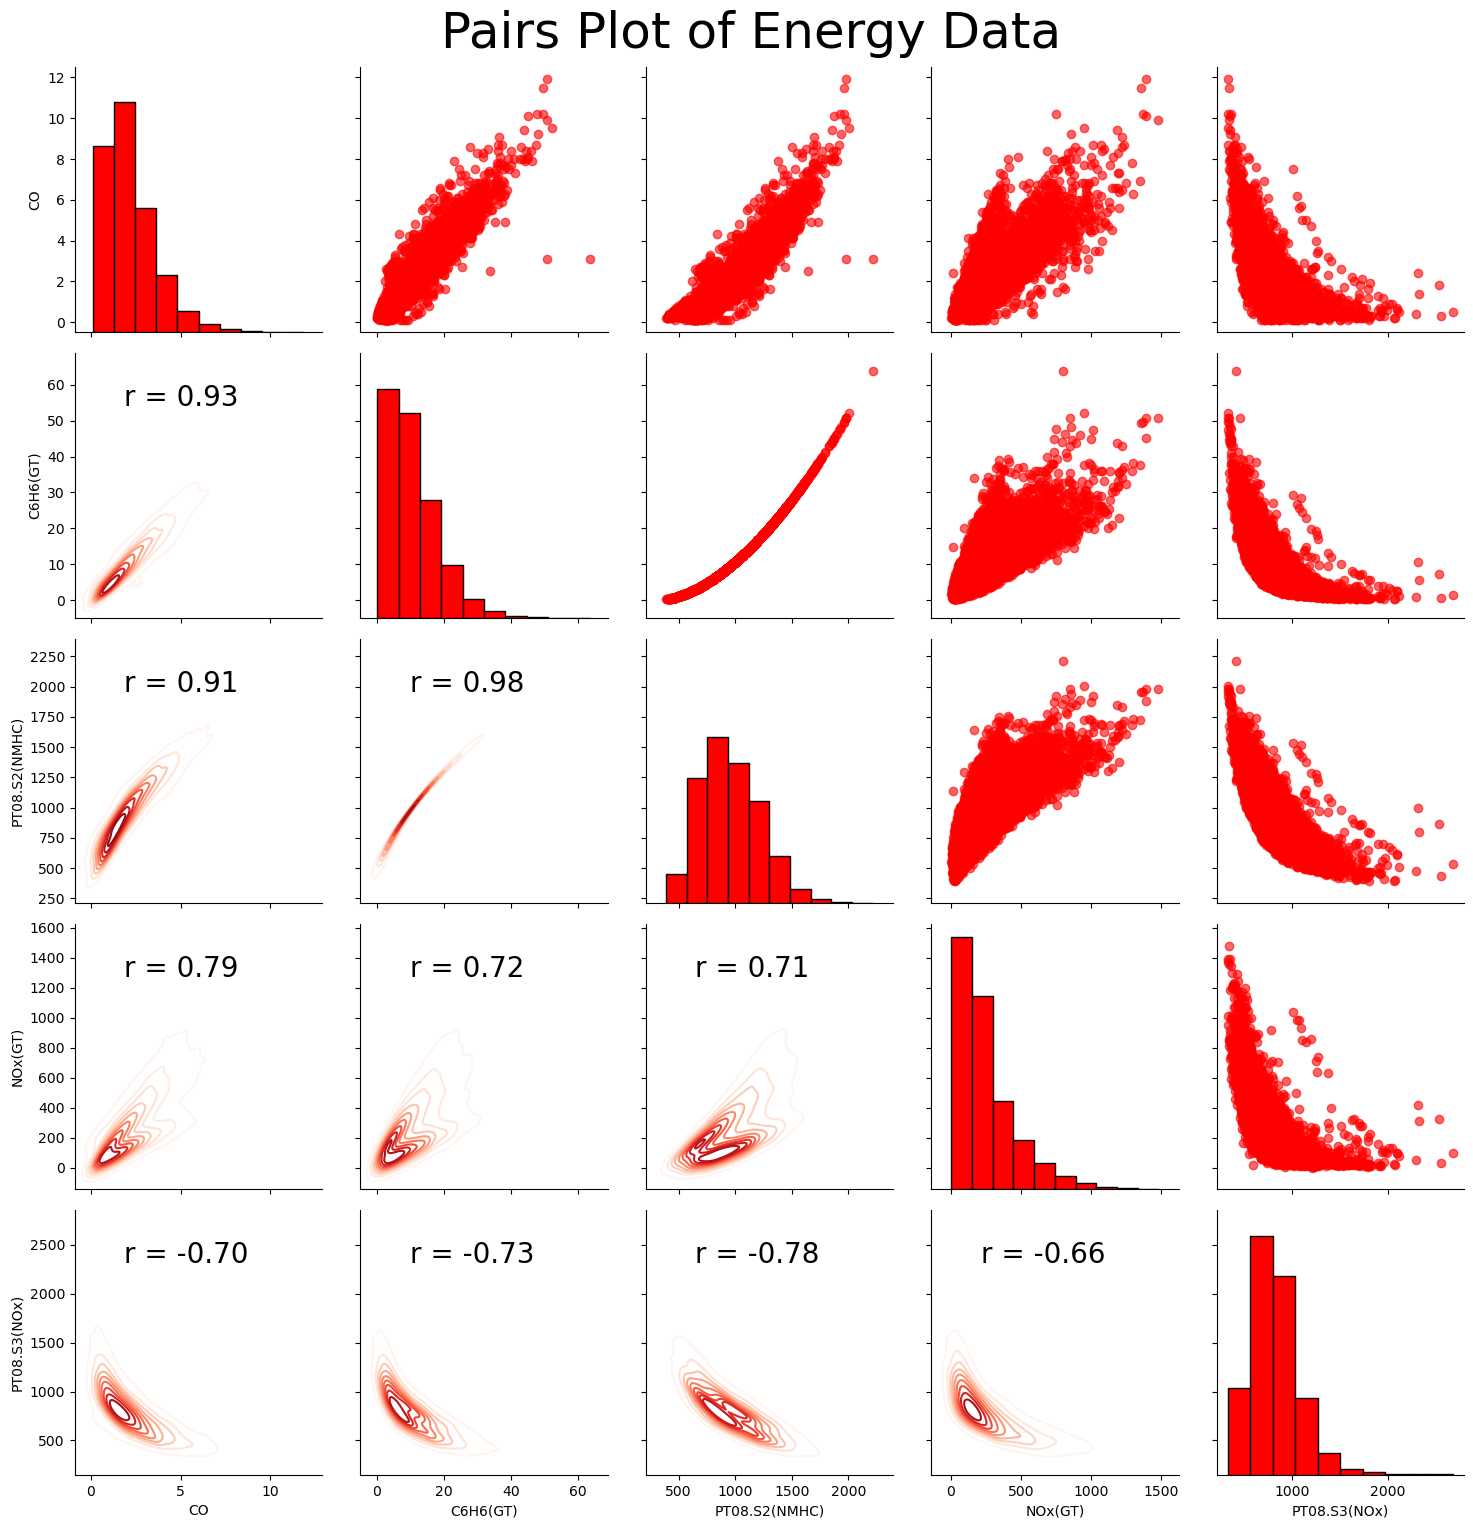

In [15]:
# Extract the columns to plot
plot_data = features[['CO', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)']]
# Replace the inf with nan
plot_data = plot_data.replace({np.inf: np.nan, -np.inf: np.nan})
# Drop na values
plot_data = plot_data.dropna()
# Function to calculate correlation coefficient between two columns
def corr_func(x, y, **kwargs):
 r = np.corrcoef(x, y)[0][1]
 ax = plt.gca()
 ax.annotate("r = {:.2f}".format(r),
 xy=(.2, .8), xycoords=ax.transAxes,
 size = 20)
# Create the pairgrid object
grid = sns.PairGrid(data=plot_data, height=3) # Use 'height' instead of 'size'
# Upper is a scatter plot
grid.map_upper(plt.scatter, color='red', alpha=0.6)
# Diagonal is a histogram
grid.map_diag(plt.hist, color='red', edgecolor='black')
# Bottom is correlation and density plot
grid.map_lower(corr_func) # Correlation coefficient
grid.map_lower(sns.kdeplot, cmap=plt.cm.Reds) # KDE plot
# Title for entire plot
plt.suptitle('Pairs Plot of Energy Data', size=36, y=1.02)

In [16]:
features.shape

(9471, 37)

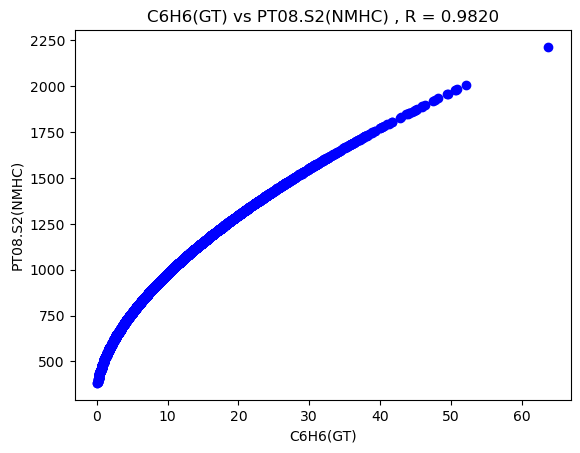

In [17]:
#Drop NaN values for the selected columns
plot_data = df[['C6H6(GT)', 'PT08.S2(NMHC)']].dropna()
# Compute the correlation coefficient
correlation = np.corrcoef(plot_data['C6H6(GT)'],
 plot_data['PT08.S2(NMHC)'])[0, 1]
# Scatter plot
plt.plot(plot_data['C6H6(GT)'], plot_data['PT08.S2(NMHC)'], 'bo')
# Labels and title
plt.xlabel('C6H6(GT)')
plt.ylabel('PT08.S2(NMHC)')
plt.title(f'C6H6(GT) vs PT08.S2(NMHC) , R = {correlation:.4f}') # Using f-string for better readability
# Show the plot
plt.show()

In [18]:
df.columns
features.columns


Index(['CO', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
       'AH', 'sqrt_PT08.S1(CO)', 'log_PT08.S1(CO)', 'sqrt_C6H6(GT)',
       'log_C6H6(GT)', 'sqrt_PT08.S2(NMHC)', 'log_PT08.S2(NMHC)',
       'sqrt_NOx(GT)', 'log_NOx(GT)', 'sqrt_PT08.S3(NOx)', 'log_PT08.S3(NOx)',
       'sqrt_NO2(GT)', 'log_NO2(GT)', 'sqrt_PT08.S4(NO2)', 'log_PT08.S4(NO2)',
       'sqrt_PT08.S5(O3)', 'log_PT08.S5(O3)', 'sqrt_T', 'log_T', 'sqrt_RH',
       'log_RH', 'sqrt_AH', 'log_AH', 'hour', 'month', 'Datetime'],
      dtype='object')

In [19]:
def remove_collinear_features(x, threshold):

    # Keep CO separately
    y = x['CO']
    x = x.drop(columns=['CO'])

    # Columns NOT to include in correlation
    exclude_cols = ['hour', 'month', 'Datetime']
    
    # Only drop if they exist
    existing_exclude = [col for col in exclude_cols if col in x.columns]

    x_numeric = x.drop(columns=existing_exclude)

    # Correlation matrix
    corr_matrix = x_numeric.corr()

    iters = range(len(corr_matrix.columns) - 1)
    drop_cols = []

    for i in iters:
        for j in range(i):
            val = abs(corr_matrix.iloc[j, i])
            if val >= threshold:
                colname = corr_matrix.columns[i]
                drop_cols.append(colname)

    # Drop correlated features
    x_numeric = x_numeric.drop(columns=set(drop_cols))

    # Add back excluded columns
    x_clean = pd.concat([x_numeric, x[existing_exclude]], axis=1)

    # Add target back
    x_clean['CO'] = y

    return x_clean
 

In [20]:
features=remove_collinear_features(features,0.6);
features=features.dropna(axis=1,how='all')
features.shape

(9471, 8)

In [21]:
features.columns

Index(['PT08.S1(CO)', 'T', 'RH', 'log_AH', 'hour', 'month', 'Datetime', 'CO'], dtype='object')

In [22]:
# Separate rows with CO
no_CO = features[features['CO'].isna()]
CO_data = features[features['CO'].notnull()]
print("Rows without CO:", no_CO.shape)
print("Rows with CO:", CO_data.shape)

# Sort by datetime to maintain chronological order
CO_data = CO_data.sort_values(by='Datetime')

# Separate features and target
X = CO_data.drop(columns='CO')
y = CO_data['CO']

# Replace inf/-inf with NaN
X = X.replace({np.inf: np.nan, -np.inf: np.nan})

# Time-based split: first 70% for training, last 30% for testing
split_index = int(0.7 * len(X))
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Rows without CO: (1797, 8)
Rows with CO: (7674, 8)
X_train shape: (5371, 7)
X_test shape: (2303, 7)
y_train shape: (5371,)
y_test shape: (2303,)


In [23]:
# Function to calculate mean absolute error
def mae(y_true, y_pred):
 return np.mean(abs(y_true - y_pred))

In [24]:
baseline_guess = np.median(y)
print('The baseline guess is a score of %0.2f' % baseline_guess)
print("Baseline Performance on the test set: MAE = %0.4f" % mae(y_test, baseline_guess))

The baseline guess is a score of 1.80
Baseline Performance on the test set: MAE = 1.0780


In [25]:
# Save the no scores, training, and testing data
no_CO.to_csv('no_CO.csv', index = False)
X.to_csv('training_features.csv', index = False)
X_test.to_csv('testing_features.csv', index = False)
y.to_csv('training_labels.csv', index = False)
y_test.to_csv('testing_labels.csv', index = False)